In [13]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, precision_score, recall_score)

df = pd.read_csv('telecom_master.csv')

print(df.shape)
print(df['churn'].value_counts(normalize=True).round(3))

(3000, 22)
churn
0    0.767
1    0.233
Name: proportion, dtype: float64


In [5]:
target = 'churn'
leaky  = ['retention_call_flag', 'total_charges']   # replace with your own findings
 
def make_X(frame, drop):
    X = frame.drop(columns=[target] + drop + ['customer_id'])
    return X
 
num_cols = make_X(df, leaky).select_dtypes(include=np.number).columns.tolist()
cat_cols = make_X(df, leaky).select_dtypes(exclude=np.number).columns.tolist()
print(len(num_cols), 'numeric,', len(cat_cols), 'categorical')
print('complaint_intensity' in num_cols)   # should print True


14 numeric, 4 categorical
False


In [6]:
X = make_X(df, leaky)
y = df[target]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
 
pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])


In [7]:
models = {
    'Logistic regression': LogisticRegression(max_iter=2000),
    'Decision tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random forest':       RandomForestClassifier(n_estimators=300,
                                                  min_samples_leaf=3, random_state=42),
}
 
results = []
for name, clf in models.items():
    pipe = Pipeline([('pre', pre), ('clf', clf)]).fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    results.append({
        'model':     name,
        'roc_auc':   roc_auc_score(y_test, proba),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall':    recall_score(y_test, pred),
        'accuracy':  (pred == y_test).mean(),
    })
 
comparison = pd.DataFrame(results).round(3)
comparison


,model,roc_auc,precision,recall,accuracy
0,Logistic regression,0.770,0.543,0.251,0.776
1,Decision tree,0.709,0.423,0.234,0.747
2,Random forest,0.758,0.509,0.166,0.768


In [8]:
best = Pipeline([('pre', pre), ('clf', models['Random forest'])]).fit(X_train, y_train)
proba = best.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, (proba >= 0.5).astype(int))
tn, fp, fn, tp = cm.ravel()
print(f'TN {tn}  FP {fp}  FN {fn}  TP {tp}')
print(classification_report(y_test, (proba >= 0.5).astype(int), digits=3))



TN 547  FP 28  FN 146  TP 29
              precision    recall  f1-score   support

           0      0.789     0.951     0.863       575
           1      0.509     0.166     0.250       175

    accuracy                          0.768       750
   macro avg      0.649     0.559     0.556       750
weighted avg      0.724     0.768     0.720       750



In [9]:
baseline_accuracy = 1 - y_test.mean()
print('Predict nobody churns  - accuracy:', round(baseline_accuracy, 3))
print('Random forest at 0.5   - accuracy:', round(((proba >= 0.5).astype(int) == y_test).mean(), 3))


Predict nobody churns  - accuracy: 0.767
Random forest at 0.5   - accuracy: 0.768


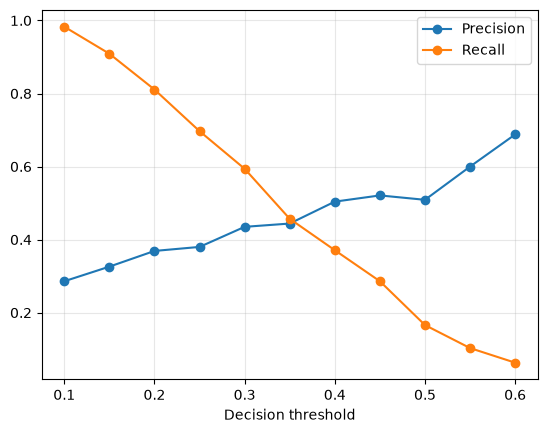

,threshold,precision,recall,flagged
0,0.10,0.286,0.983,601
1,0.15,0.326,0.909,488
2,0.20,0.369,0.811,385
3,0.25,0.380,0.697,321
4,0.30,0.435,0.594,239
5,0.35,0.444,0.457,180
6,0.40,0.504,0.371,129
7,0.45,0.521,0.286,96
8,0.50,0.509,0.166,57
9,0.55,0.600,0.103,30


In [10]:
rows = []
for t in np.arange(0.10, 0.65, 0.05):
    pred = (proba >= t).astype(int)
    rows.append({'threshold': round(t, 2),
                 'precision': precision_score(y_test, pred, zero_division=0),
                 'recall':    recall_score(y_test, pred),
                 'flagged':   int(pred.sum())})
sweep = pd.DataFrame(rows).round(3)
 
plt.plot(sweep.threshold, sweep.precision, marker='o', label='Precision')
plt.plot(sweep.threshold, sweep.recall,    marker='o', label='Recall')
plt.xlabel('Decision threshold'); plt.legend(); plt.grid(alpha=.3); plt.show()
sweep


In [11]:
COST_FN, COST_FP = 5880, 300
sweep['expected_cost'] = 0
for i, t in enumerate(sweep.threshold):
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    sweep.loc[i, 'expected_cost'] = fn * COST_FN + fp * COST_FP
sweep.sort_values('expected_cost').head()


,threshold,precision,recall,flagged,expected_cost
0,0.10,0.286,0.983,601,146340
1,0.15,0.326,0.909,488,192780
2,0.20,0.369,0.811,385,266940
3,0.25,0.380,0.697,321,371340
4,0.30,0.435,0.594,239,457980


In [12]:
import pandas as pd
import numpy as np

print("Libraries loaded!")

Libraries loaded!


In [14]:
# Check whether model prediction variables are available

print("y_test available:", "y_test" in globals())
print("y_pred available:", "y_pred" in globals())

y_test available: True
y_pred available: False


In [15]:
y_pred = pipeline.predict(X_test)

print("Prediction completed!")
print("y_test:", len(y_test))
print("y_pred:", len(y_pred))

NameError: name 'pipeline' is not defined

In [16]:
target = "churn"

X = df.drop(columns=[target, "customer_id"], errors="ignore")
y = df[target]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Model trained successfully!")
print("y_test:", len(y_test))
print("y_pred:", len(y_pred))

Model trained successfully!
y_test: 600
y_pred: 600


In [17]:
churn_dashboard = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred
})

churn_dashboard["Actual_Label"] = churn_dashboard["Actual_Churn"].map({
    0: "Not Churned",
    1: "Churned"
})

churn_dashboard["Predicted_Label"] = churn_dashboard["Predicted_Churn"].map({
    0: "Not Churned",
    1: "Churned"
})

churn_dashboard.to_csv(
    "Churn_PowerBI_Dashboard.csv",
    index=False
)

print("Power BI dashboard data created successfully!")
print("File: Churn_PowerBI_Dashboard.csv")
print("Rows:", len(churn_dashboard))

churn_dashboard.head()

Power BI dashboard data created successfully!
File: Churn_PowerBI_Dashboard.csv
Rows: 600


,Actual_Churn,Predicted_Churn,Actual_Label,Predicted_Label
0,0,0,Not Churned,Not Churned
1,0,0,Not Churned,Not Churned
2,0,0,Not Churned,Not Churned
3,0,0,Not Churned,Not Churned
4,1,1,Churned,Churned
